In [1]:
!pip install groq --quiet

import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs found: {tf.config.list_physical_devices('GPU')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.6 MB/s eta 0:00:00


2026-04-23 14:49:50.225846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776955790.429945      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776955790.491427      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776955790.983186      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776955790.983231      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776955790.983234      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [1]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.6 MB/s eta 0:00:00


In [2]:
import os, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from groq import Groq
from kaggle_secrets import UserSecretsClient
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("All imports successful ✅")

2026-04-23 16:31:38.390006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776961898.622878      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776961898.686177      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776961899.223164      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776961899.223199      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776961899.223202      55 computation_placer.cc:177] computation placer alr

All imports successful ✅


In [3]:
data_path = '/kaggle/input/datasets/sonu7676/data-for-tensorflow'
df = pd.read_excel(f'{data_path}/balanced_edufeed_dataset (2).xlsx')
df = df[['comments', 'sentiment_label']].dropna()
df['comments'] = df['comments'].astype(str).str.strip()

print(f'Total samples: {len(df)}')
print('\nOriginal label distribution:')
print(df['sentiment_label'].value_counts())
df.head()

Total samples: 35417

Original label distribution:
sentiment_label
Neutral     11807
Negative    11807
Positive    11803
Name: count, dtype: int64


,comments,sentiment_label
0,"This class is hard, but its a two-in-one gen-e...",Positive
1,Definitely going to choose Prof. Looney\'s cla...,Positive
2,I overall enjoyed this class because the assig...,Positive
3,"Yes, it\'s possible to get an A but you\'ll de...",Positive
4,Professor Looney has great knowledge in Astron...,Positive


In [4]:
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret('llm')
client = Groq(api_key=api_key)

VALID_LABELS = {'positive', 'negative', 'neutral'}
CACHE_PATH   = '/kaggle/working/groq_labels.csv'

def groq_classify(text: str, retries: int = 3) -> str:
    prompt = (
        'Classify the sentiment of the following educational feedback comment.\n'
        'Reply with ONLY one word: Positive, Negative, or Neutral.\n\n'
        f'Comment: {text}\n\nSentiment:'
    )
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model='llama-3.1-8b-instant',
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=5,
                temperature=0.0
            )
            raw = resp.choices[0].message.content.strip().lower()
            for word in re.split(r'\W+', raw):
                if word in VALID_LABELS:
                    return word.capitalize()
            return 'Neutral'
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f'[WARN] Failed after {retries} attempts: {e}')
                return 'Neutral'

print("Groq client ready ✅")

Groq client ready ✅


In [5]:
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret('llm')
client = Groq(api_key=api_key)

VALID_LABELS = {'positive', 'negative', 'neutral'}
CACHE_PATH   = '/kaggle/working/groq_labels.csv'

def groq_classify(text: str, retries: int = 3) -> str:
    prompt = (
        'Classify the sentiment of the following educational feedback comment.\n'
        'Reply with ONLY one word: Positive, Negative, or Neutral.\n\n'
        f'Comment: {text}\n\nSentiment:'
    )
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model='llama-3.1-8b-instant',
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=5,
                temperature=0.0
            )
            raw = resp.choices[0].message.content.strip().lower()
            for word in re.split(r'\W+', raw):
                if word in VALID_LABELS:
                    return word.capitalize()
            return 'Neutral'
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f'[WARN] Failed after {retries} attempts: {e}')
                return 'Neutral'

print("Groq client ready ✅")

Groq client ready ✅


In [6]:
print(df['comments'].str.len().describe())

count    35417.000000
mean       206.376373
std        114.200848
min          1.000000
25%        110.000000
50%        219.000000
75%        319.000000
max        739.000000
Name: comments, dtype: float64


In [7]:
if os.path.exists(CACHE_PATH):
    print("Cache found! Loading...")
else:
    print("No cache — will call Groq API for all 35k rows")

No cache — will call Groq API for all 35k rows


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow import keras
import numpy as np

# Encode labels
label_encoder = LabelEncoder()
df['label_enc'] = label_encoder.fit_transform(df['sentiment_label'])
NUM_CLASSES = len(label_encoder.classes_)
print('Label mapping:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X = df['comments'].values
y = df['label_enc'].values

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Label mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
Train: 24791 | Val: 5313 | Test: 5313


In [12]:
import re
import pandas as pd

PATTERNS = [
    (re.compile(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'), '<EMAIL>'),
    (re.compile(r'(\+91[\-\s]?)?[6-9]\d{9}'), '<PHONE>'),
    (re.compile(r'http\S+|www\.\S+'), '<URL>'),
    (re.compile(r'\b[A-Z]{2,4}\d{2,4}[A-Z]{0,3}\d{0,4}\b'), '<ID>'),
    (re.compile(r'\b\d{5,}\b'), '<NUM>'),
    (re.compile(r'(?<![.\n])\b[A-Z][a-z]{2,}(?:\s[A-Z][a-z]{2,})*\b'), '<NAME>'),
]

def anonymize_text(text):
    if pd.isna(text):
        return ""
    for pattern, repl in PATTERNS:
        text = pattern.sub(repl, text)
    return text.strip()

df['comments'] = df['comments'].apply(anonymize_text)

print("Anonymization done ✅")
print(df['comments'].head())

Anonymization done ✅
0    <NAME> class is hard, but its a two-in-one gen...
1    <NAME> going to choose <NAME>. <NAME>\'s class...
2    I overall enjoyed this class because the assig...
3    <NAME>, it\'s possible to get an A but you\'ll...
4    <NAME> has great knowledge in <NAME>, while he...
Name: comments, dtype: object


In [13]:
# Fastest tokenization — tf.data pipeline + vectorization
import tensorflow as tf

MAX_LEN   = 100
VOCAB_SIZE = 20000
EMBEDDING_DIM = 64

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN,
    split='whitespace',       # faster than default
    ngrams=None               # no ngrams = faster
)

# adapt on small sample — vocab stabilizes at 5k rows
vectorizer.adapt(X_train[:5000])

X_train_pad = vectorizer(X_train).numpy()
X_val_pad   = vectorizer(X_val).numpy()
X_test_pad  = vectorizer(X_test).numpy()

y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_cat   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f'X_train_pad shape: {X_train_pad.shape}')
print("Data ready ✅")

X_train_pad shape: (24791, 100)
Data ready ✅


In [14]:
import tensorflow as tf

# Use both GPUs
strategy = tf.distribute.MirroredStrategy()
print(f'GPUs: {strategy.num_replicas_in_sync}')

with strategy.scope():
    inp = keras.Input(shape=(MAX_LEN,))
    x   = keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM)(inp)
    x   = keras.layers.SpatialDropout1D(0.2)(x)
    x   = keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True, dropout=0.2))(x)
    x   = keras.layers.Bidirectional(keras.layers.LSTM(32, dropout=0.2))(x)
    x   = keras.layers.Dense(64, activation='relu')(x)
    x   = keras.layers.Dropout(0.4)(x)
    out = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs: 2


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,391,619 (5.31 MB)

 Trainable params: 1,391,619 (5.31 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_accuracy', save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=128,   # large batch = faster on 2x T4
    callbacks=callbacks
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1776962055.647837     161 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776962055.795771     159 cuda_dnn.cc:529] Loaded cuDNN version 91002


194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4486 - loss: 1.0057INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.4492 - loss: 1.0051 - val_accuracy: 0.7111 - val_loss: 0.6905 - learning_rate: 0.0010
Epoch 2/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.7336 - loss: 0.6567 - val_accuracy: 0.7728 - val_loss: 0.5770 - learning_rate: 0.0010
Epoch 3/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.7941 - loss: 0.5351 - val_accuracy: 0.8005 - val_loss: 0.5263 - learning_rate: 0.0010
Epoch 4/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8311 - loss: 0.4454 - val_accuracy: 0.8154 - val_loss: 0.5148 - learning_rate: 0.0010
Epoch 5/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 

Test Accuracy : 0.8637
Test Loss     : 0.5204
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

── Classification Report ──
              precision    recall  f1-score   support

    Negative       0.84      0.94      0.88      1772
     Neutral       0.86      0.88      0.87      1771
    Positive       0.90      0.77      0.83      1770

    accuracy                           0.86      5313
   macro avg       0.87      0.86      0.86      5313
weighted avg       0.87      0.86      0.86      5313



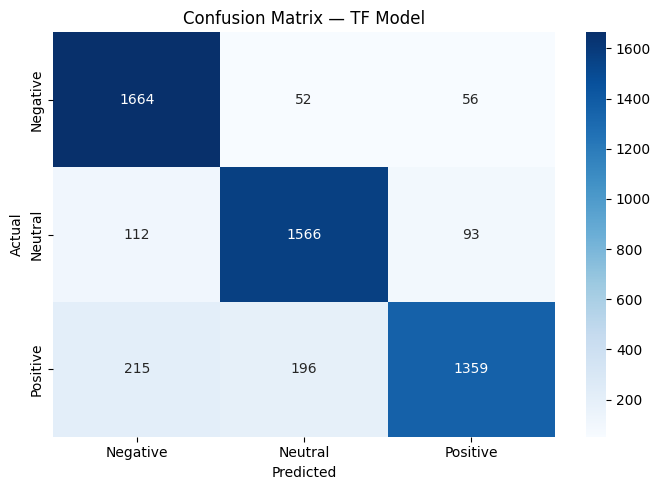

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = keras.models.load_model('/kaggle/working/best_model.keras')

test_loss, test_acc = best_model.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

y_pred = np.argmax(best_model.predict(X_test_pad), axis=1)

print('\n── Classification Report ──')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix — TF Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [17]:
import joblib
from tensorflow import keras
from groq import Groq

# ── LOAD ─────────────────────────────────────────────────────────────────
model = keras.models.load_model('/kaggle/working/best_model.keras')
# vectorizer  ← already in memory from training cell
# label_encoder ← already in memory from training cell
# client (Groq) ← already in memory

print("Model loaded ✅")
print("Label classes:", label_encoder.classes_)

Model loaded ✅
Label classes: ['Negative' 'Neutral' 'Positive']
